TASK 1:DATA CLEANING AND PREPROCESSING

#Import Required Libraries

In [1]:
import pandas as pd

#Load the Dataset

In [2]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\Sentiment dataset.csv")     

#Check or inspect data

In [1]:
df.head()

NameError: name 'df' is not defined

#Check Data Structure

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Text       732 non-null    object        
 1   Sentiment  732 non-null    object        
 2   Timestamp  732 non-null    datetime64[ns]
 3   User       732 non-null    object        
 4   Platform   732 non-null    object        
 5   Hashtags   732 non-null    object        
 6   Retweets   732 non-null    float64       
 7   Likes      732 non-null    float64       
 8   Country    732 non-null    object        
 9   Year       732 non-null    int64         
 10  Month      732 non-null    int64         
 11  Day        732 non-null    int64         
 12  Hour       732 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(4), object(6)
memory usage: 74.5+ KB


#Checking for Missing Value - No missing value were found in the dataset

In [25]:
df.isnull().sum()

Text         0
Sentiment    0
Timestamp    0
User         0
Platform     0
Hashtags     0
Retweets     0
Likes        0
Country      0
Year         0
Month        0
Day          0
Hour         0
dtype: int64

#Handling missing value for numerical values

In [30]:
df["Likes"] = df["Likes"].fillna(df["Likes"].mean())

#Handling missing value for text values

In [31]:
df["Country"] = df["Country"].fillna("Unknown")

#Check for Duplicate Value-No duplicate value found

In [32]:
df.duplicated().sum()

np.int64(21)

In [35]:
duplicates = df.duplicated().sum()

print(duplicates)

0


#Remove duplicate (In case there is duplicate values in the dataset

In [34]:
df = df.drop_duplicates()

#Remove Unnecessary Columns- The dataset contain an extran column: Unnamed: 0, Unnamed: 0.1

#Check if the extra column is removed

In [37]:
df.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,CANADA,2023,1,15,8
2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,AUSTRALIA,2023,1,15,19


#Standardize Date Format
#Convert the Timestamp column to proper datetime format

In [38]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

#Check if the timestamp daterime has been formated

In [39]:
df["Timestamp"].head()

0   2023-01-15 12:30:00
1   2023-01-15 08:45:00
2   2023-01-15 15:45:00
3   2023-01-15 18:20:00
4   2023-01-15 19:55:00
Name: Timestamp, dtype: datetime64[ns]

#Standardize Text Columns
#Some values contain extra spaces.
#Remove leading and trailing spaces:

In [40]:
df["Sentiment"] = df["Sentiment"].str.strip()
df["Platform"] = df["Platform"].str.strip()
df["Country"] = df["Country"].str.strip()
df["User"] = df["User"].str.strip()
df["Text"] = df["Text"].str.strip()

#check if space are removed

In [41]:
df.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,CANADA,2023,1,15,8
2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,AUSTRALIA,2023,1,15,19


#Standardize Capitalization
#Convert text to title case:

In [17]:
df["Country"] = df["Country"].str.upper()
df["Platform"] = df["Platform"].str.title()
df["Sentiment"] = df["Sentiment"].str.title()

In [47]:
df.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User 123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,Commuter X,Twitter,#Traffic #Morning,5.0,10.0,CANADA,2023,1,15,8
2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,Fitness Fan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,Adventure X,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,Chef Cook,Instagram,#Cooking #Food,12.0,25.0,AUSTRALIA,2023,1,15,19


#Check for Datatype

In [19]:
df.dtypes

Text                 object
Sentiment            object
Timestamp    datetime64[ns]
User                 object
Platform             object
Hashtags             object
Retweets            float64
Likes               float64
Country              object
Year                  int64
Month                 int64
Day                   int64
Hour                  int64
dtype: object

#Seperate the text in user column

In [42]:
import re

    # Insert space between lowercase and uppercase letters
    # Insert space between letters and numbers
    # Insert space between numbers and letters

In [45]:
def clean_text(text):
    text = re.sub(r'([a-z])([A-Z])', r'\1 \2', text)
    text = re.sub(r'([A-Za-z])([0-9])', r'\1 \2', text)
    text = re.sub(r'([0-9])([A-Za-z])', r'\1 \2', text)

    return text
    

In [46]:
df['User'] = df['User'].apply(clean_text)

#Save the Cleaned Dataset

In [48]:
df.to_csv("cleaned_sentiment_dataset23.csv", index=False) 

TASK 2: Exploratory Data Analysis (EDA)

#Understand the Dataset
#Check Shape

In [24]:
df.shape

(732, 13)

#View Column names

In [25]:
df.columns

Index(['Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags',
       'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour'],
      dtype='object')

#Generate Summary Statistics for numerical columns

In [26]:
df.describe()

,Timestamp,Retweets,Likes,Year,Month,Day,Hour
count,732,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000
mean,2020-12-08 21:37:38.196721408,21.508197,42.901639,2020.471311,6.122951,15.497268,15.521858
min,2010-05-15 15:30:00,5.000000,10.000000,2010.000000,1.000000,1.000000,0.000000
25%,2019-03-08 17:27:30,17.750000,34.750000,2019.000000,3.000000,9.000000,13.000000
50%,2021-09-20 14:30:00,22.000000,43.000000,2021.000000,6.000000,15.000000,16.000000
75%,2023-02-26 11:48:45,25.000000,50.000000,2023.000000,9.000000,22.000000,19.000000
max,2023-10-22 20:45:00,40.000000,80.000000,2023.000000,12.000000,31.000000,23.000000
std,NaN,7.061286,14.089848,2.802285,3.411763,8.474553,4.113414


#Calculate mean ( Mean for Likes)

In [27]:
df["Likes"].mean()

np.float64(42.90163934426229)

#Calculate mean ( Mean for all numeric values)

In [28]:
df.mean(numeric_only=True)

Retweets      21.508197
Likes         42.901639
Year        2020.471311
Month          6.122951
Day           15.497268
Hour          15.521858
dtype: float64

#Calculate median ( Mean for all numeric values)

In [29]:
df.median(numeric_only=True)

Retweets      22.0
Likes         43.0
Year        2021.0
Month          6.0
Day           15.0
Hour          16.0
dtype: float64

#Calculate Mode

In [48]:
df.mode()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,"A compassionate rain, tears of empathy falling...",Positive,2018-08-22 17:20:00,Bookworm,Instagram,#Compassionate #TearsOfEmpathy,22.0,45.0,USA,2023.0,2.0,15.0,14.0
1,"A playful escapade in the carnival of life, ca...",NaN,2019-04-05 17:30:00,Carnival Dreamer,NaN,#Hopeful #SeedsOfOptimism,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Embraced by the hopeful dawn, a gardener sowin...",NaN,2020-01-05 08:45:00,Dawn Gardener,NaN,#Playful #CarnivalEscapade,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Proudly scaling the peaks of achievement, a mo...",NaN,2021-07-01 12:10:00,Forest Dreamer,NaN,#Proud #ScalingPeaks,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,2022-07-17 06:15:00,Nature Admirer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaT,Peak Conqueror,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaT,Rain Nurturer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaT,Wind Whisperer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaT,Winter Warmth,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#Calculate Mode(For a particular Column)

In [31]:
df["Sentiment"].mode()

0    Positive
Name: Sentiment, dtype: object

#Calculate Standard Deviation (for all numerical values)

In [32]:
df.std(numeric_only=True)

Retweets     7.061286
Likes       14.089848
Year         2.802285
Month        3.411763
Day          8.474553
Hour         4.113414
dtype: float64

VISUALIZE DATA DISTRIBUTION 

#import visualization libraries

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
import matplotlib
import seaborn

print(matplotlib.__version__)
print(seaborn.__version__)

3.9.4
0.13.2


#Histogram for Likes (A histogram shows how data is distributed.)

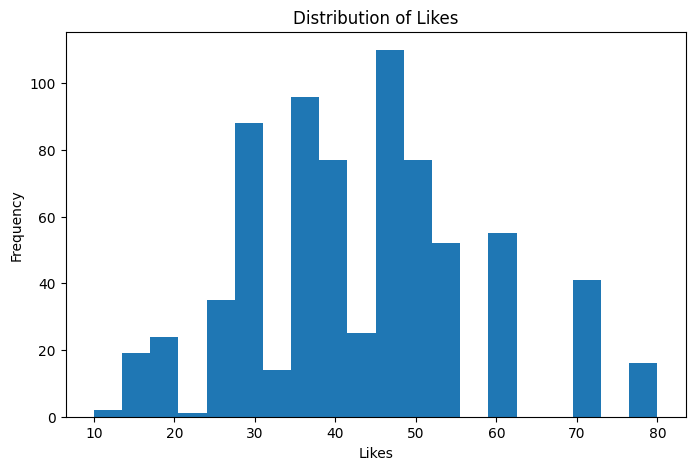

In [36]:
plt.figure(figsize=(8,5))
plt.hist(df["Likes"], bins=20)
plt.title("Distribution of Likes")
plt.xlabel("Likes")
plt.ylabel("Frequency")
plt.savefig("likes_trend.png")
plt.show()

#Histogram for Retweet

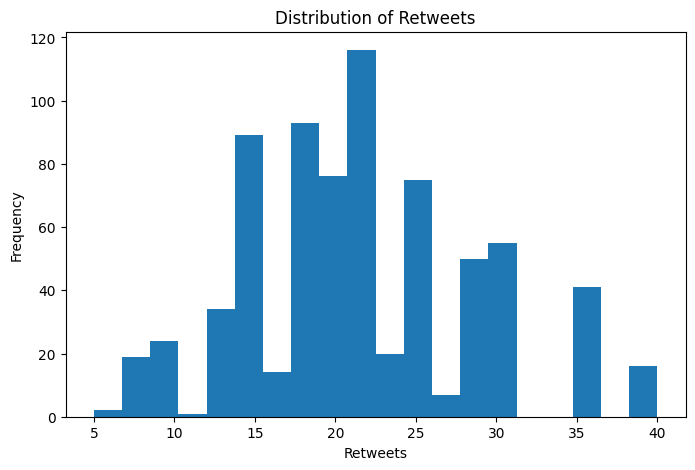

In [50]:
plt.figure(figsize=(8,5))
plt.hist(df["Retweets"], bins=20)
plt.title("Distribution of Retweets")
plt.xlabel("Retweets")
plt.ylabel("Frequency")
plt.savefig("retweet_trend.png")
plt.show()

#Boxplot for Likes (A boxplot identifies outliers)

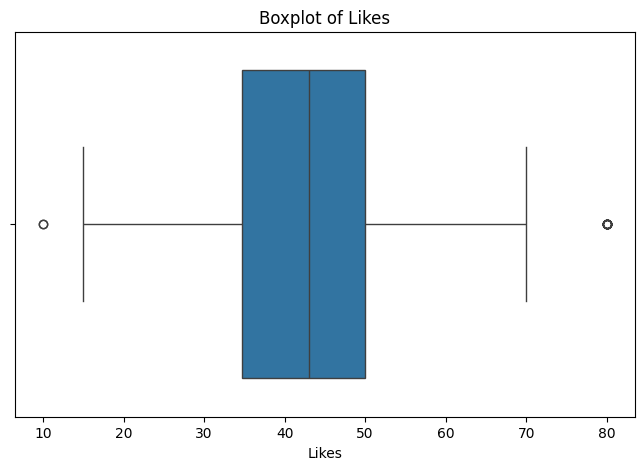

In [52]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Likes"])
plt.title("Boxplot of Likes")
plt.savefig("boxplot_likes.png")
plt.show()

#Boxplot for Retweet

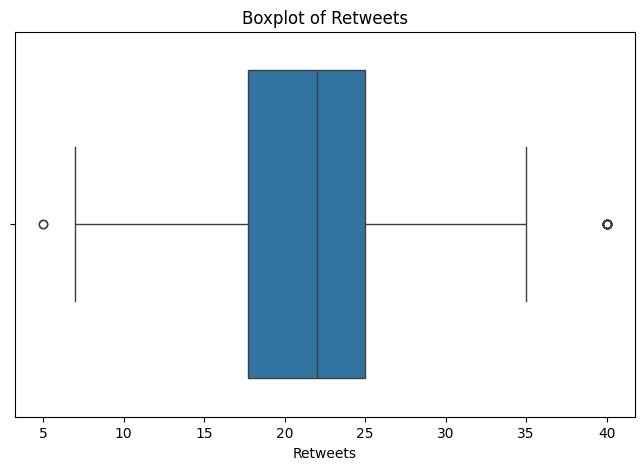

In [53]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Retweets"])
plt.title("Boxplot of Retweets")
plt.show()

#Scatter Plots(Scatter plots show relationships between variables)
#Likes vs Retweet

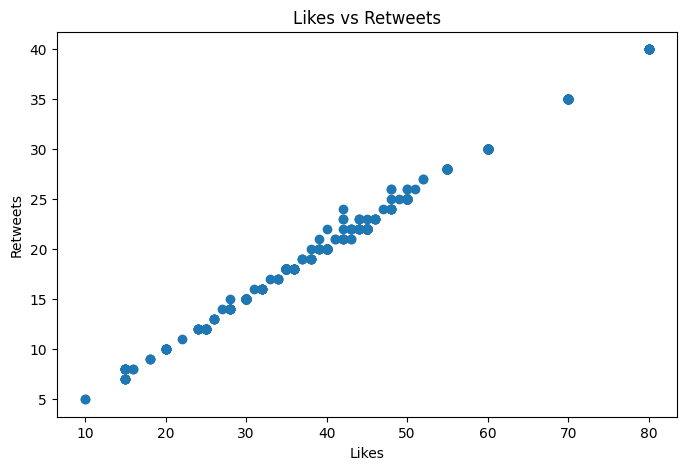

In [54]:
plt.figure(figsize=(8,5))
plt.scatter(df["Likes"], df["Retweets"])
plt.title("Likes vs Retweets")
plt.xlabel("Likes")
plt.ylabel("Retweets")
plt.savefig("boxplot_likesvsretweet.png")
plt.show()

#Sentiment Distribution

In [55]:
df["Sentiment"].value_counts()

Sentiment
Positive                45
Joy                     44
Excitement              37
Contentment             19
Neutral                 18
                        ..
Celestial Wonder         1
Nature'S Beauty          1
Thrilling Journey        1
Whispers Of The Past     1
Relief                   1
Name: count, Length: 191, dtype: int64

#Visualize

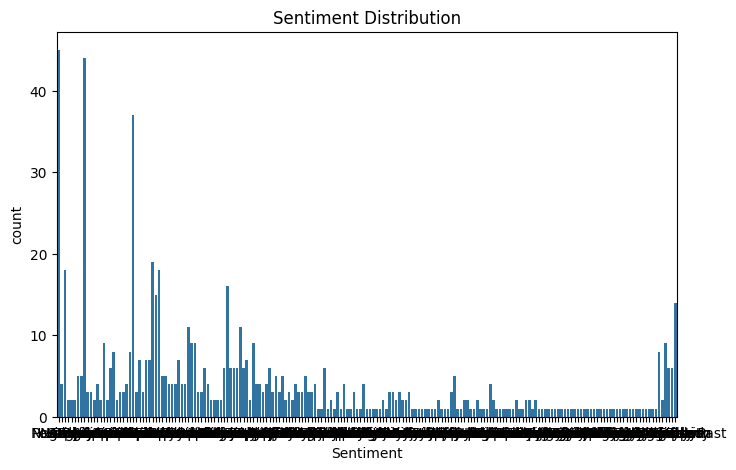

In [56]:
plt.figure(figsize=(8,5))
sns.countplot(x="Sentiment", data=df)
plt.title("Sentiment Distribution")
plt.savefig("sentiment_distribution_count.png")
plt.show()

#Platform Distribution

In [51]:
df["Platform"].value_counts()

Platform
Instagram    258
Twitter      243
Facebook     231
Name: count, dtype: int64

#Platform Visualization 

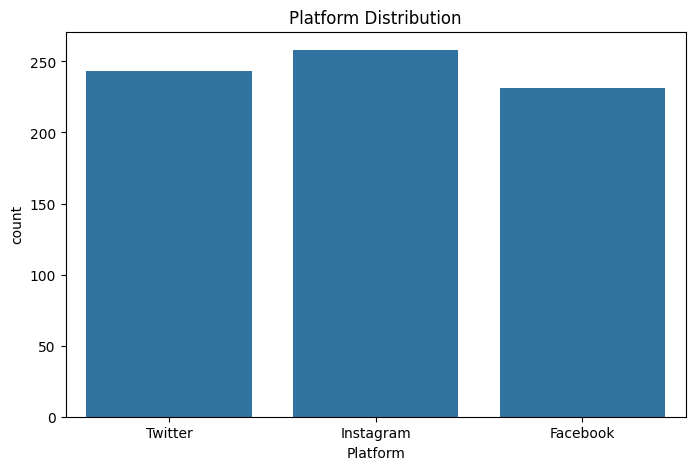

In [57]:
plt.figure(figsize=(8,5))
sns.countplot(x="Platform", data=df)
plt.title("Platform Distribution")
plt.savefig("platform_distribution.png")
plt.show()

#Correlation Analysis(Find relationships among numerical variables)
#Select numeriacl columns

In [59]:
numerical_cols = df.select_dtypes(include=['int64','float64'])

#View correlation matrix

In [60]:
numerical_cols.corr()

,Retweets,Likes,Year,Month,Day,Hour
Retweets,1.000000,0.998482,-0.039982,0.073265,0.009213,0.196955
Likes,0.998482,1.000000,-0.043415,0.066643,0.011489,0.195331
Year,-0.039982,-0.043415,1.000000,-0.314845,0.021973,-0.087470
Month,0.073265,0.066643,-0.314845,1.000000,-0.135873,0.137835
Day,0.009213,0.011489,0.021973,-0.135873,1.000000,0.044072
Hour,0.196955,0.195331,-0.087470,0.137835,0.044072,1.000000


#Correlation Heatmap

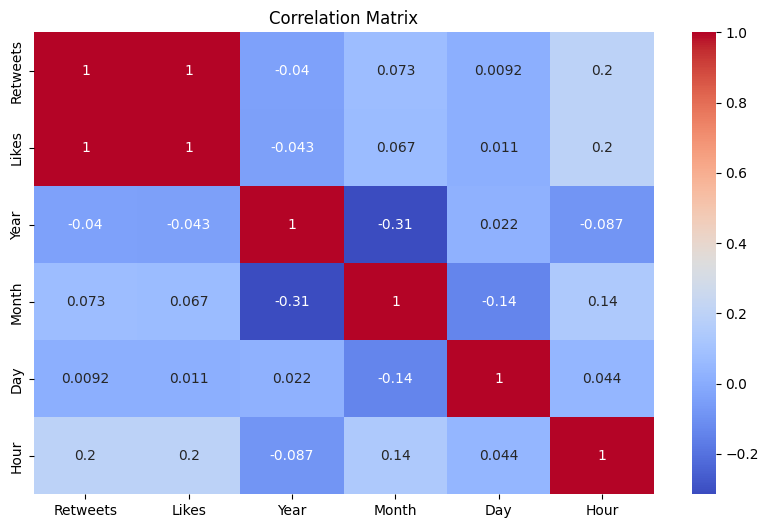

In [61]:
plt.figure(figsize=(10,6))
sns.heatmap(
    numerical_cols.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.savefig("correlation_matrix.png")
plt.show()

STEP 3: BASIC DATA VISUALIZATION

#Bar Plot *Count of Sentiment)

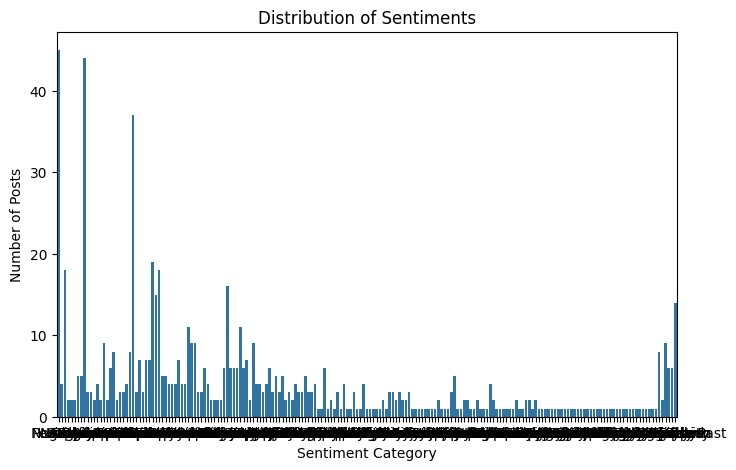

In [56]:
plt.figure(figsize=(8,5))

sns.countplot(x='Sentiment', data=df)

plt.title("Distribution of Sentiments")
plt.xlabel("Sentiment Category")
plt.ylabel("Number of Posts")

plt.savefig("sentiment_distribution.png")

plt.show()

In [ ]:
#Line Chart

In [57]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [ ]:
#Daily Engagement Trend

In [58]:
daily_likes = df.groupby(df['Timestamp'].dt.date)['Likes'].mean()

In [ ]:
#plot

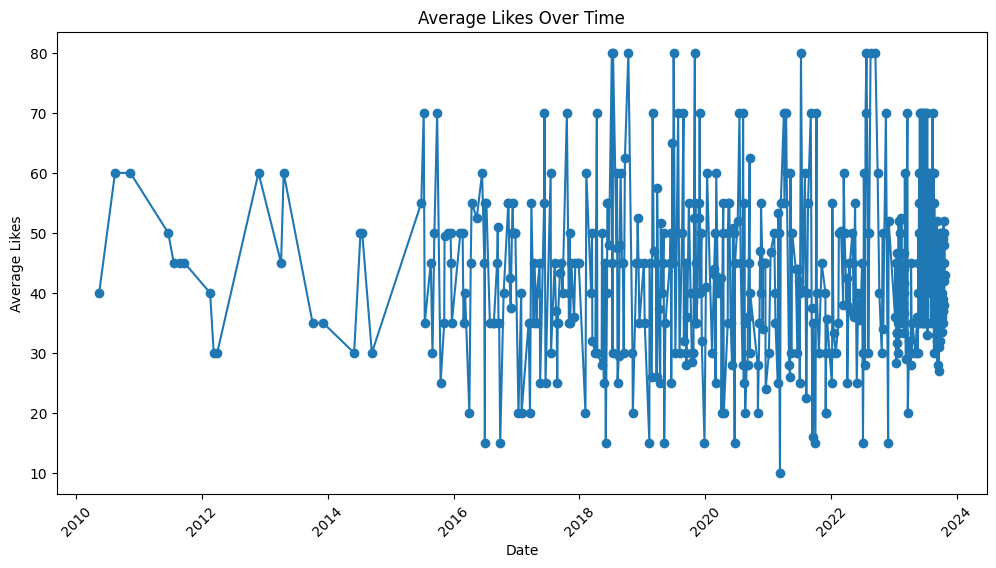

In [60]:
plt.figure(figsize=(12,6))

plt.plot(daily_likes.index,
         daily_likes.values,
         marker='o')

plt.title("Average Likes Over Time")
plt.xlabel("Date")
plt.ylabel("Average Likes")

plt.xticks(rotation=45)

plt.savefig("likes_trend.png")

plt.show()

In [ ]:
#Scatter Plot(LIke and Retweet)

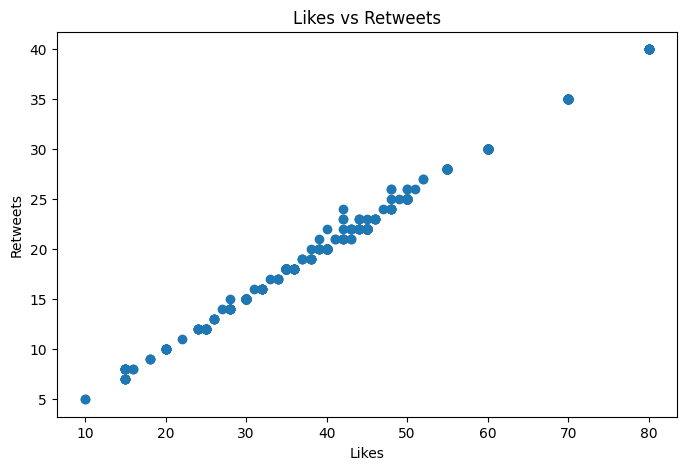

In [62]:
plt.figure(figsize=(8,5))

plt.scatter(df['Likes'],
            df['Retweets'])

plt.title("Likes vs Retweets")
plt.xlabel("Likes")
plt.ylabel("Retweets")
plt.savefig("scatterplot_likesvsretweet.png")
plt.show()

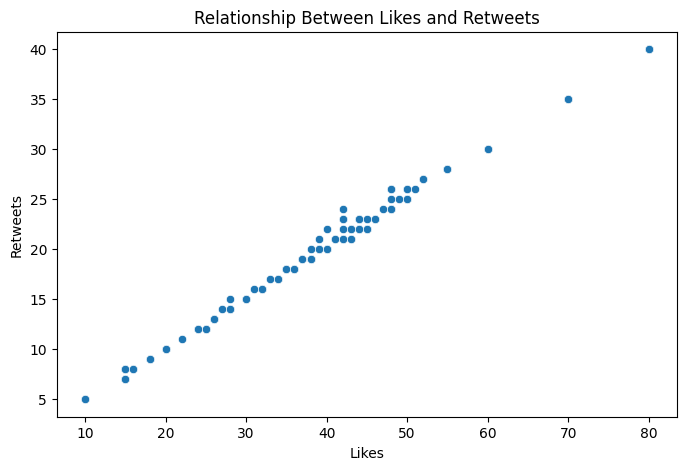

In [63]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Likes',
    y='Retweets',
    data=df
)
plt.title("Relationship Between Likes and Retweets")
plt.xlabel("Likes")
plt.ylabel("Retweets")
plt.savefig("Relationship_Between_Likes_and_Retweets.png")
plt.show()

In [63]:
plt.savefig("likes_retweets_relationship.png")

<Figure size 640x480 with 0 Axes>

In [ ]:
#Legend

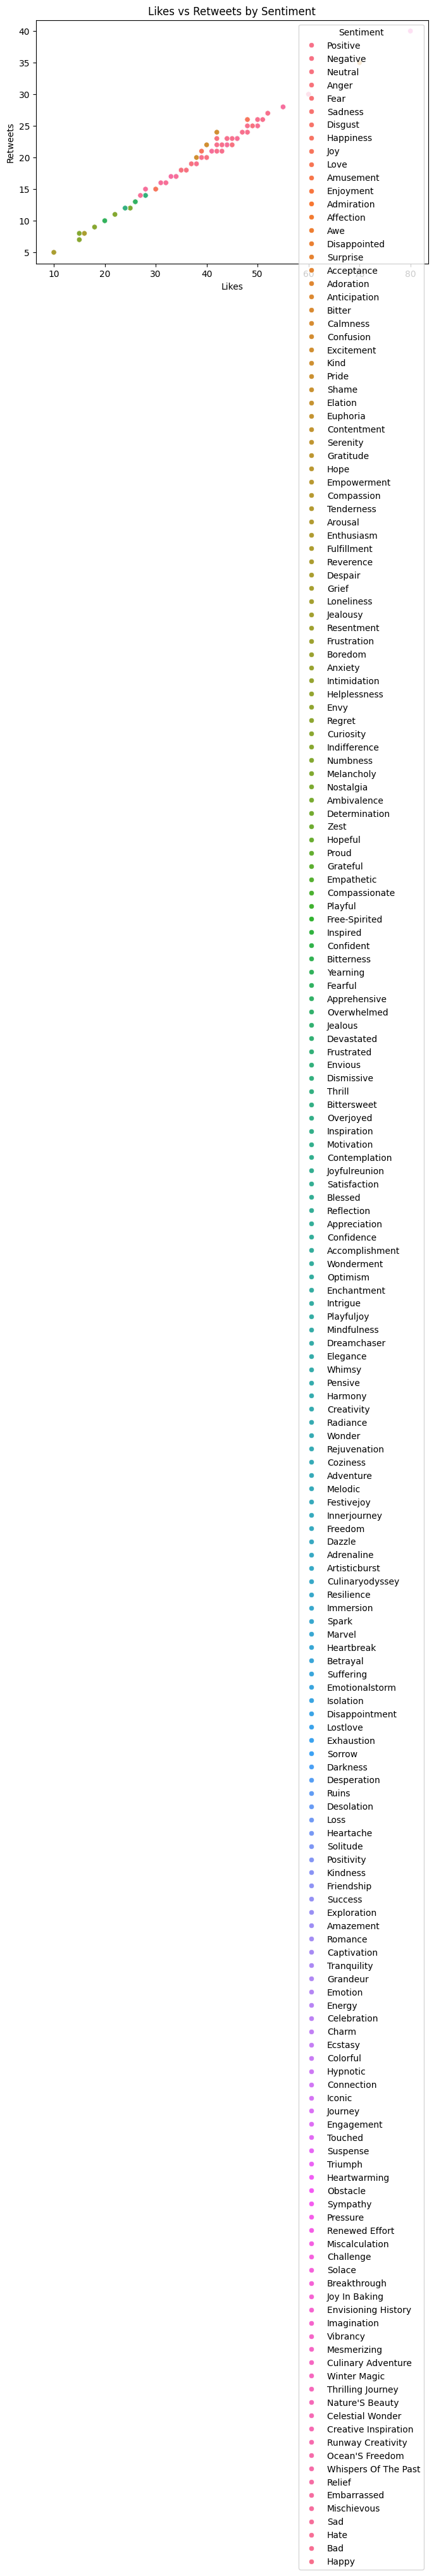

In [64]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Likes',
    y='Retweets',
    hue='Sentiment',
    data=df
)
plt.title("Likes vs Retweets by Sentiment")
plt.xlabel("Likes")
plt.ylabel("Retweets")

plt.legend(title="Sentiment")
plt.savefig("Likes_vs_Retweets_Sentiment.png")
plt.show()

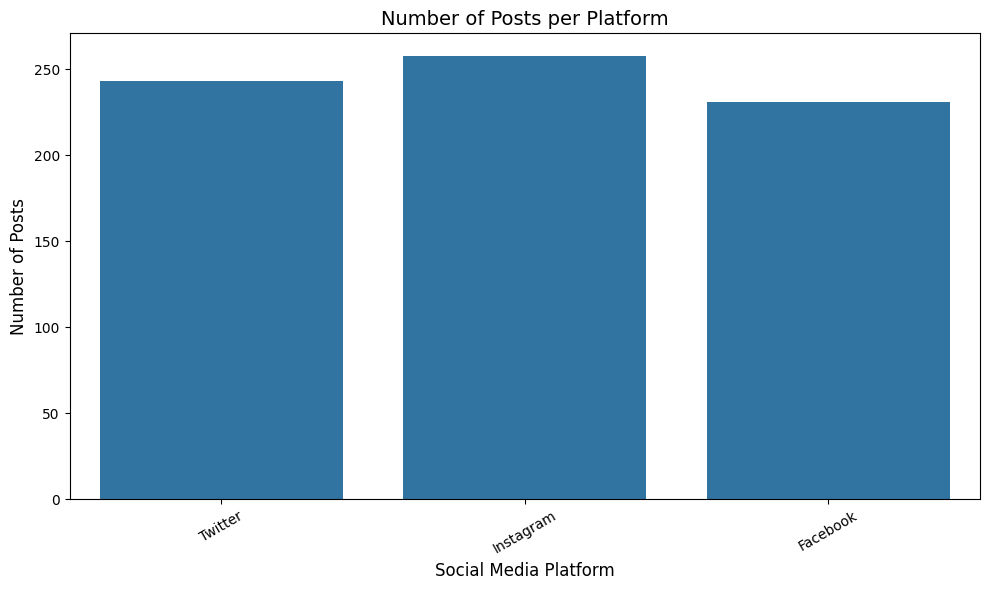

In [65]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='Platform',
    data=df
)

plt.title(
    "Number of Posts per Platform",
    fontsize=14
)

plt.xlabel(
    "Social Media Platform",
    fontsize=12
)

plt.ylabel(
    "Number of Posts",
    fontsize=12
)

plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("number_of_post_per_platform.png")
plt.show()

In [66]:
print(df.columns.tolist())

['Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']
